We represent the steps as a nested list of steps. Each step consists of a metric + method, where the metric gives some diagnostic information and the method applies some kind of change to the dataset. Broadly, steps fall in either two categories: those that change the shape of the dataset, and those that change the distribution of the values within the dataset:

- Changing data shape (Filtering): mask features or samples
- Changing data distribution (Normalization/Batch Correction): move & rescale samples or features

Each step consists of a metric to answer a given question (e.g. computing data completeness, outliers, distributions, clustering) and a method that changes the data. For example, checking the metric data completeness and seeing that 12 % of features are less than 10 % complete across all samples could inform using a method for filtering for data completeness. Checking for completeness and removing incomplete features would then constitute one step in the analysis of a dataset. An ideal analysis would then be a sequence of steps, each of which consists of metric + method.

In [29]:
%load_ext autoreload
%autoreload 2

import alphapepttools as apt
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from msmetrics.datasets import wu2025
from msmetrics import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load data

In [30]:
adata = ad.read_h5ad(wu2025())
adata

AnnData object with n_obs × n_vars = 2599 × 4279
    obs: 'ID', 'celltype', 'sample'
    layers: None (.X)

### 2. Preprocessing

In [31]:
# Data is already log-transformed!
# adata_log = apt.pp.nanlog(adata, copy = True)

# Drop samples that are missing annotation
adata = adata[adata.obs["celltype"].notna()]

### 3. Visualize data completeness (QC-inspection)

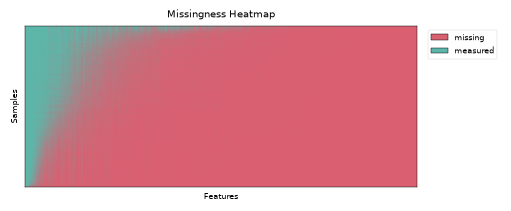

--> Dropping too incomplete features


INFO:root:pp.filter_data_completeness(): drop 3730 / 4279 features with >0.60 missing fraction.


--> Dropping too outlier samples
Removing 274 outlier samples: more than 3 MADs from the median


In [32]:
utils.draw_missingness(
    X=adata.X,
    xlabel="Features",
    ylabel="Samples",
    title="Missingness Heatmap",
)

# Flag features that are more than 60 % missing
print("--> Dropping too incomplete features", flush = True)
adata = apt.pp.filter_data_completeness(
    adata = adata,
    max_missing_fraction = 0.6,
    action = "drop",
)

# Compute actual completeness in features
apt.metrics.fraction_complete(
    adata=adata,
)

# Compute median intensity of features
adata.obs["median_intensity"] = np.nanmedian(adata.X, axis=1)

# Flag outliers based on median absolute deviation
adata.obs["outlier"] = utils.mad_outlier(adata.obs["fraction_complete"], n_mad=3, direction="down") | utils.mad_outlier(
    adata.obs["median_intensity"], n_mad=3, direction="both"
)

# Remove outliers
print("--> Dropping too outlier samples", flush = True)
print(f"Removing {adata.obs['outlier'].sum()} outlier samples: more than 3 MADs from the median", flush = True)
adata = adata[~adata.obs["outlier"]]



### 4. Normalization

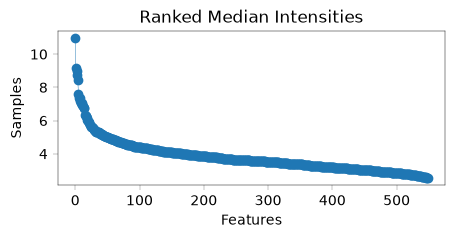

Total sum of squares: 1.878e+05
Variance explained by median_intensity: 19.52 % = 3.665e+04
Variance explained by celltype: 21.46 % = 4.029e+04


/Users/vincenthbrennsteiner/miniconda3/envs/msmetrics/lib/python3.12/site-packages/alphapepttools/tl/embeddings.py:180: ImplicitModificationWarning: Setting element `.obsm['X_bpca_obs']` of view, initializing view as actual.
  coords_dict[pca_coords_key] = pc_mat
/Users/vincenthbrennsteiner/miniconda3/envs/msmetrics/lib/python3.12/site-packages/alphapepttools/tl/embeddings.py:181: ImplicitModificationWarning: Setting element `.varm['PCs_bpca_obs']` of view, initializing view as actual.
  loadings_dict[loadings_key] = loadings_mat
/Users/vincenthbrennsteiner/miniconda3/envs/msmetrics/lib/python3.12/site-packages/alphapepttools/metrics/principal_component_regression.py:162: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(y):


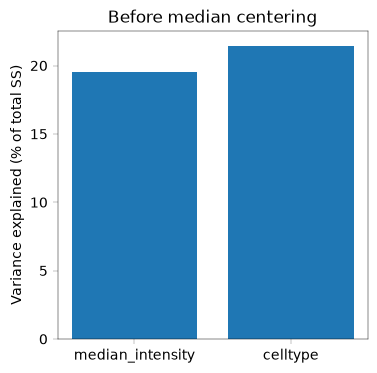

In [33]:
# Visualize the median ranked intensities
utils.draw_ranked_median_intensities(
    X=adata.X,
    xlabel="Features",
    ylabel="Samples",
    title="Ranked Median Intensities",
)

# <Diagnose>
# Quantify how much of the variance is explained by median intensity (i.e. how much material was
# loaded per sample) versus by celltype. If the loading amount explains as much as the biology,
# a global median normalization step is warranted.
#
# BPCA is used for the decomposition because it handles the missing values directly.
before = utils.diagnose_covariates(
    adata,
    ["median_intensity", "celltype"],
    n_comps=10,
    title="Before median centering",
)

In [34]:
# <Diagnose>
# Where does that median-intensity variance sit? On log scale, differences in loading amount are
# additive and hit every feature equally, so they form a rank-1 block along the all-ones direction
# in feature space. BPCA centers per feature across samples, which does nothing to a per-sample
# offset, so that block survives into the components: we expect it to concentrate in the leading
# PCs, and those PCs to carry near-flat, single-signed loading vectors.
pcs = adata.obsm["X_bpca_obs"]
loadings = adata.varm["PCs_bpca_obs"]
variance_ratio = adata.uns["variance_bpca_obs"]["variance_ratio"]
median_intensity = np.asarray(adata.obs["median_intensity"], dtype=float)

# Decompose the PCR score the same way `principal_component_regression` assembles it:
#   contribution_k = variance_ratio_k * R2(median_intensity ~ PC_k),   PCR = sum_k contribution_k
contributions = pd.DataFrame(
    {
        "r": [np.corrcoef(pcs[:, k], median_intensity)[0, 1] for k in range(pcs.shape[1])],
        "variance_ratio": variance_ratio,
        # A flat, single-signed loading vector is what the all-ones direction looks like
        "loading_sign_agreement": [
            max(np.mean(loadings[:, k] > 0), np.mean(loadings[:, k] < 0)) for k in range(pcs.shape[1])
        ],
    },
    index=[f"PC{k + 1}" for k in range(pcs.shape[1])],
)
contributions["contribution"] = contributions["variance_ratio"] * contributions["r"] ** 2
contributions = contributions.sort_values("contribution", ascending=False)

print(f"Contributions sum to {contributions['contribution'].sum() * 100:.2f} %", flush=True)
contributions

Contributions sum to 19.52 %


,r,variance_ratio,loading_sign_agreement,contribution
PC1,-0.726590,0.325625,0.985428,0.171908
PC2,-0.309037,0.108106,0.506375,0.010325
PC3,0.365419,0.077104,0.597450,0.010296
PC4,-0.208863,0.060709,0.508197,0.002648
PC5,0.007491,0.000000,0.528233,0.000000
PC6,-0.007491,0.000000,0.528233,0.000000
PC7,0.007491,0.000000,0.528233,0.000000
PC8,0.007491,0.000000,0.528233,0.000000
PC9,0.007491,0.000000,0.528233,0.000000
PC10,0.007491,0.000000,0.528233,0.000000


#### Observation:

Median intensity explains almost as much variance in the dataset as our celltype, and the
decomposition above shows where it sits: the bulk of it rides on the leading principal component,
whose loading vector is essentially flat and single-signed. That is the signature of a per-sample
offset rather than of biology, so median normalization should remove it. We evaluate that in the
cell below.

Note that this is *per-sample* centering, not a global one. A single constant subtracted from the
whole matrix would only translate the cloud and could not change any variance decomposition. Here
every sample gets its own offset, so the samples move by different amounts along the same axis and
the spread along that axis collapses.

INFO:root:pp.scale_and_center(): Scaling data with robust scaler.


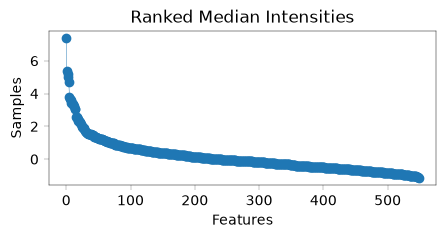

Total sum of squares: 1.498e+05
Variance explained by median_intensity: 1.42 % = 2131
Variance explained by celltype: 21.55 % = 3.228e+04


/Users/vincenthbrennsteiner/miniconda3/envs/msmetrics/lib/python3.12/site-packages/alphapepttools/metrics/principal_component_regression.py:162: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(y):


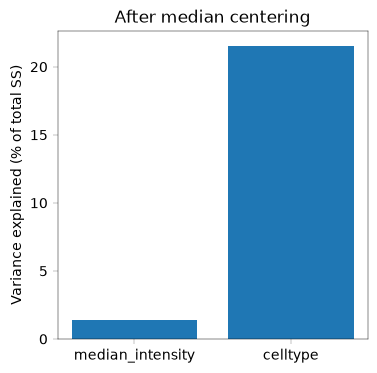

In [35]:
# Apply median normalization
adata = adata.transpose() # we need to normalize samples, so we transpose the data to have samples columns
apt.pp.scale_and_center(
    adata=adata,
    scaler="robust",
    scale=False,
    center=True,
)
adata = adata.transpose() # transpose back to have features as columns


# Visualize the median ranked intensities
utils.draw_ranked_median_intensities(
    X=adata.X,
    xlabel="Features",
    ylabel="Samples",
    title="Ranked Median Intensities",
)

# <Diagnose>
# `median_intensity` is deliberately still the value measured *before* centering: we are asking
# whether the original loading-depth signal still explains structure in the normalized data.
after = utils.diagnose_covariates(
    adata,
    ["median_intensity", "celltype"],
    n_comps=10,
    title="After median centering",
)

#### Reading these two diagnostics side by side

Two things are easy to get wrong here:

1. **`median_intensity` must stay the pre-normalization value.** It is computed once in step 3 and
   never recomputed. Recomputing it after centering would give exactly zero for every sample, since
   that is what the centering enforces, and the regression would return ~0 % for trivial reasons
   rather than because the effect was removed.
2. **The two percentages are not on the same scale.** Principal component regression reports a
   fraction of the total variance *of the matrix it was handed*, and normalization shrank that
   total. So a covariate whose percentage stays flat has actually lost absolute variance. That is
   why `diagnose_covariates` also returns `total_ss` and an `<covariate>_absolute` entry; compare
   those across the two calls.

The residual explained by median intensity does not go to zero, and should not: some biology is
genuinely correlated with loading depth, the PCR implementation clamps each component at
`max(0, R2)` which biases a ten-component sum upward, and BPCA components are not exactly
orthogonal.

In [36]:
# Compare on the absolute scale rather than on the renormalized fractions
comparison = pd.DataFrame(
    {
        "before": [before["median_intensity"], before["celltype"], before["total_ss"]],
        "after": [after["median_intensity"], after["celltype"], after["total_ss"]],
    },
    index=["median_intensity (fraction)", "celltype (fraction)", "total_ss"],
)
comparison["absolute_before"] = [before["median_intensity_absolute"], before["celltype_absolute"], np.nan]
comparison["absolute_after"] = [after["median_intensity_absolute"], after["celltype_absolute"], np.nan]
comparison

,before,after,absolute_before,absolute_after
median_intensity (fraction),0.195176,0.014229,36652.087484,2130.779576
celltype (fraction),0.214566,0.215526,40293.156191,32275.984763
total_ss,187789.519640,149754.181080,NaN,NaN


 ### 5. Imputation

### 6. Batch correction

### 7. Differential expression (out of scope)